<a href="https://colab.research.google.com/github/Vidhya-95/deep_learning/blob/main/Deep_Learning_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

2026-03-19 11:48:36.442973: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773920916.616077      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773920916.665621      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773920917.084208      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773920917.084251      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773920917.084254      55 computation_placer.cc:177] computation placer alr

In [ ]:
#Setting seed for reproducibility
tf.random.set_seed(42)

# Understanding the cifar10 dataset:
The 10 represents 10 different classes labelled 0 to 9. There are 50000 training dataset and 10000 testing dataset.

In [ ]:
#Loading dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
print("Shape of training dataset : ",X_train.shape)
print("Shape of testing dataset : ",X_test.shape)

Shape of training dataset :  (50000, 32, 32, 3)
Shape of testing dataset :  (10000, 32, 32, 3)


# Data Preprocessing

## Resizing and Normalization:
- We are **resizing** images to have 224*224 pixels (with 3 channels RGB) for uniformity in image size.
- **Normalizing** the pixel values converts each pixel value between 0 and 1. This helps us to train our model and converge faster as values are smaller.

In [ ]:
img_size = 224
resize_and_rescale = keras.Sequential([
  layers.Resizing(img_size, img_size),
  layers.Rescaling(1./255)
])

## Data Augmentation
We will be using keras image preprocessing layers to perform augmentation. This will enable to train our model on a large amount of data and create a generalized model and prevent overfitting.

In [ ]:
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2)
])

I0000 00:00:1773920945.789913      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Model Training

In [ ]:
model = keras.Sequential([
    #Adding preprocessing layers
    resize_and_rescale,
    data_augmentation,
    #Adding convolution layers along with maxpooling
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    #Flattening the output from maxpooling for forming dense neural network
    layers.Flatten(),
    layers.Dense(128, activation='relu'), #128 here is the output units
    #Ouput layer with 10 classes
    layers.Dense(10)
])

In [ ]:
#Compiling the model
model.compile(optimizer='adam',loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=5,
    restore_best_weights=True
)

In [ ]:
#Fitting our training dataset
model_history = model.fit(
  X_train, y_train,
  epochs=50,
  batch_size=200,
  validation_split=0.2,
  callbacks=[early_stopping]
)

Epoch 1/50


I0000 00:00:1773920951.704789     274 cuda_dnn.cc:529] Loaded cuDNN version 91002


200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.2462 - loss: 2.0886 - val_accuracy: 0.3985 - val_loss: 1.6713
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.3976 - loss: 1.6831 - val_accuracy: 0.4309 - val_loss: 1.5955
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.4305 - loss: 1.5898 - val_accuracy: 0.4580 - val_loss: 1.5186
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.4465 - loss: 1.5425 - val_accuracy: 0.4702 - val_loss: 1.4837
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.4599 - loss: 1.5060 - val_accuracy: 0.4832 - val_loss: 1.4435
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.4706 - loss: 1.4777 - val_accuracy: 0.5039 - val_loss: 1.4122
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.4795 - loss: 1.4571 - val_accuracy: 0.4991 - val_loss: 1.4064
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.4872 - loss: 1.4325 - val_accurac

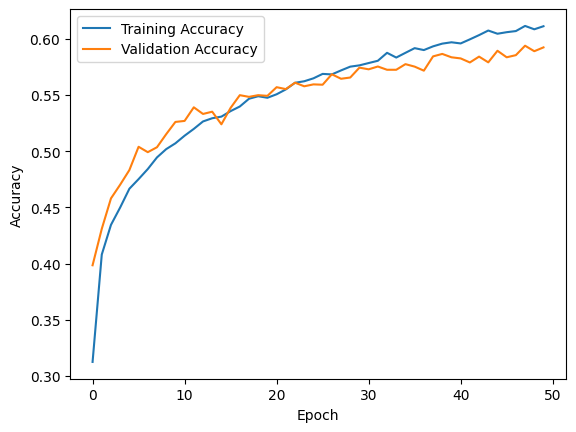

In [ ]:
#Let's plot some graphs to visualize our accuracy in training and validation as well as our loss for both
plt.plot(model_history.history['accuracy'],label = 'Training Accuracy')
plt.plot(model_history.history['val_accuracy'],label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

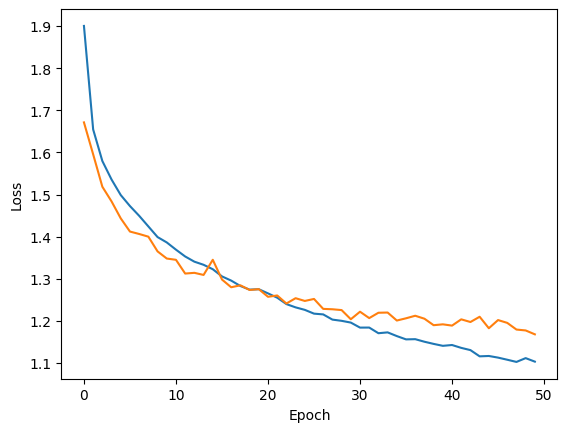

In [ ]:
plt.plot(model_history.history['loss'],label = 'Training loss')
plt.plot(model_history.history['val_loss'],label = 'Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [ ]:
#Displaying model summary
print("CNN Model Summary")
model.summary()

CNN Model Summary


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (200, 224, 224, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (200, 224, 224, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (200, 224, 224, 16)    │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (200, 112, 112, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (200, 112, 112, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (200, 56, 56, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (200, 56, 56, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (200, 28, 28, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (200, 50176)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (200, 128)             │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (200, 10)              │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,342,592 (73.79 MB)

 Trainable params: 6,447,530 (24.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,895,062 (49.19 MB)

# Model Evaluation

In [ ]:
cnn_test_loss, cnn_test_acc = model.evaluate(X_test,  y_test, verbose=2)
print("Test Loss : {:.2f}" .format(cnn_test_loss))
print("Test Accuracy : {:.2f}" .format(cnn_test_acc))

313/313 - 2s - 6ms/step - accuracy: 0.5934 - loss: 1.1520
Test Loss : 1.15
Test Accuracy : 0.59


# Implementing cnn model using Transfer Learning
We can use pre-trained models such as VGG16, ResNet50, or MobileNetV2 as our base model and fit our training data to achieve a higher accuracy as these base models are trained on a huge amount of data and its weights are optimized.Rather than building our own complex model we use pre-trained models to effectively train on our own dataset and improve accuracy.

In [ ]:
#Importing libraries for our pre-trained model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [ ]:
#Configuring our base model as InceptionV3 and removing fully connected layers by setting include_top=False
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Freeze all layers
for layer in base_model.layers:
  layer.trainable = False

In [ ]:
# Building model with base model
cnn_inceptionv3 = keras.Sequential([
    resize_and_rescale,
    data_augmentation,
    base_model,
    #You can use Flatten layer over here but to reduce the spatial dimensions and prevent overfitting GlobalAveragePooling is better option
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10,activation='softmax')
])

In [ ]:
# Compiling model
cnn_inceptionv3.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#Training the model
cnn_inceptionv3_model_history = cnn_inceptionv3.fit(
  X_train, y_train,
  epochs=50,
  batch_size=200,
  validation_split=0.2,
  callbacks=[early_stopping]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 74s 320ms/step - accuracy: 0.4614 - loss: 1.5473 - val_accuracy: 0.7556 - val_loss: 0.7280
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 306ms/step - accuracy: 0.6274 - loss: 1.0662 - val_accuracy: 0.7751 - val_loss: 0.6690
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 306ms/step - accuracy: 0.6441 - loss: 1.0152 - val_accuracy: 0.7828 - val_loss: 0.6449
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 306ms/step - accuracy: 0.6526 - loss: 0.9915 - val_accuracy: 0.7855 - val_loss: 0.6289
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 306ms/step - accuracy: 0.6660 - loss: 0.9524 - val_accuracy: 0.7947 - val_loss: 0.6080
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 305ms/step - accuracy: 0.6660 - loss: 0.9594 - val_accuracy: 0.7946 - val_loss: 0.6034
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 305ms/step - accuracy: 0.6717 - loss: 0.9380 - val_accuracy: 0.7826 - val_loss: 0.6388
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 304ms/step - accuracy: 0.6721 - loss: 0

In [ ]:
#Model Evaluation
cnn_inceptionv3_test_loss,cnn_inceptionv3_test_acc= cnn_inceptionv3.evaluate(X_test,  y_test, verbose=2)
print("Test Loss : {:.2f}" .format(cnn_inceptionv3_test_loss))
print("Test Accuracy : {:.2f}" .format(cnn_inceptionv3_test_acc))

313/313 - 19s - 62ms/step - accuracy: 0.7999 - loss: 0.5822
Test Loss : 0.58
Test Accuracy : 0.80


# CNN vs Transfer Learning
Let's plot some visuals to see the difference between the accuracy and the loss

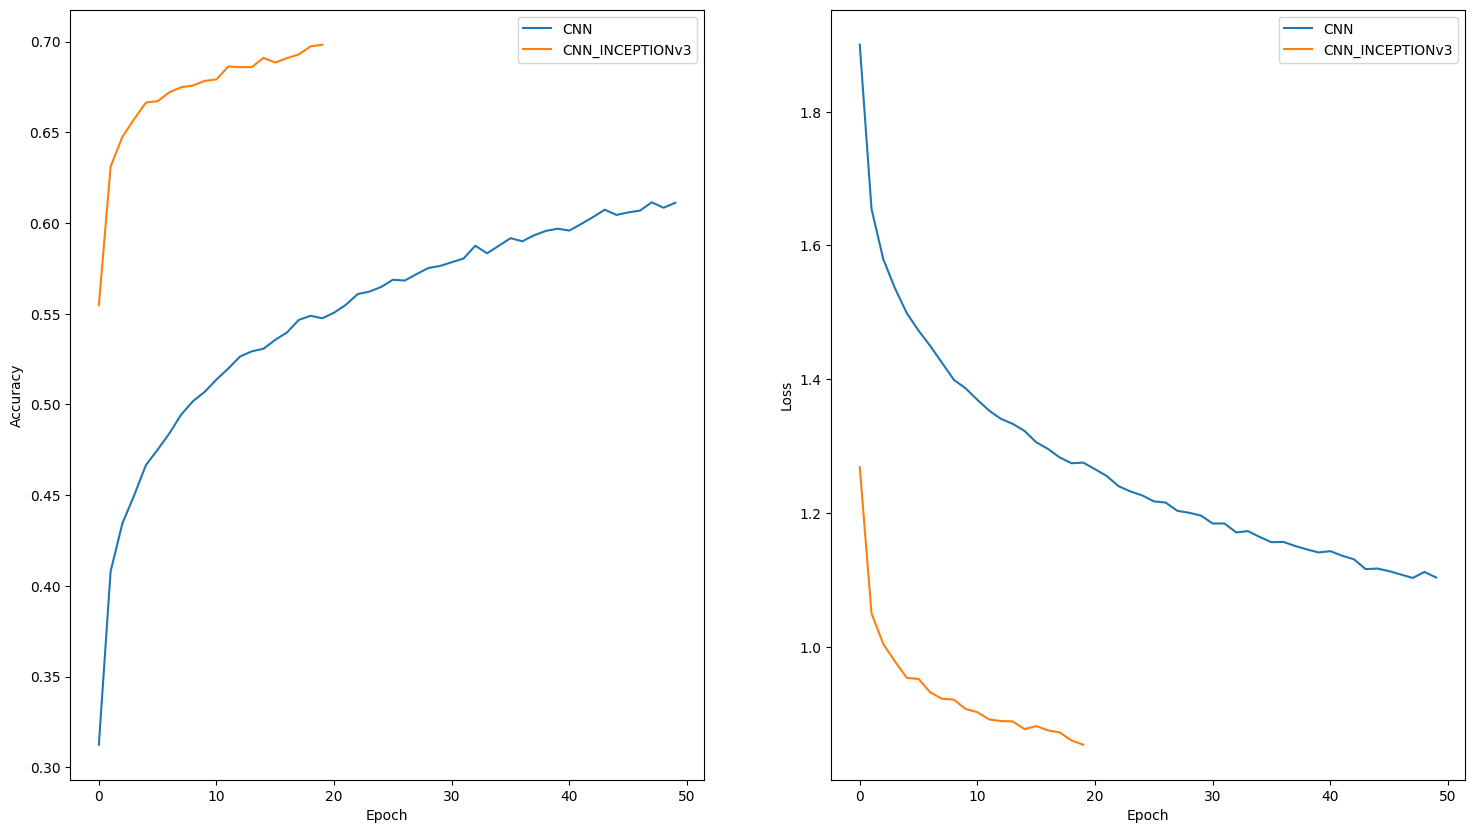

In [ ]:
plt.figure(figsize=(18,10))
plt.subplot(1,2,1)
plt.plot(model_history.history['accuracy'],label = 'CNN')
plt.plot(cnn_inceptionv3_model_history.history['accuracy'],label = 'CNN_INCEPTIONv3')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(model_history.history['loss'],label = 'CNN')
plt.plot(cnn_inceptionv3_model_history.history['loss'],label = 'CNN_INCEPTIONv3')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()



## Model Evaluation Results
* As we can see, in very few epochs cnn with pre-trained model gives us better results as compared to building our very own cnn model.
* Early stopping helps us prevent overfitting , therefore we can see results for epochs until any further improvement is seen in validation loss

In [ ]:
#Comparing Accuracy and Loss for CNN vs CNN with transfer learning
results_dict = {
    'Accuracy':[cnn_test_acc,cnn_inceptionv3_test_acc],
    'Loss':[cnn_test_loss,cnn_inceptionv3_test_loss]
}

results = pd.DataFrame(results_dict,index=['CNN','CNN+INCEPTIONv3'])

print("Model Evaluation results: \n",results)

Model Evaluation results: 
                  Accuracy      Loss
CNN                0.5934  1.151953
CNN+INCEPTIONv3    0.7999  0.582160


## Displaying sample predictions with images

In [ ]:
#Model prediction
y_pred = cnn_inceptionv3.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step


/tmp/ipykernel_55/1141886072.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = class_names[int(y_test[index])]#Actual value


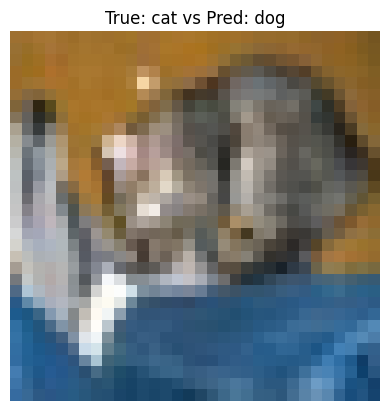

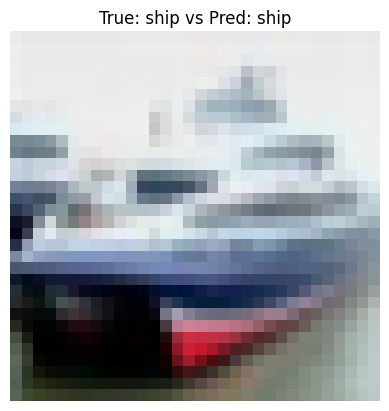

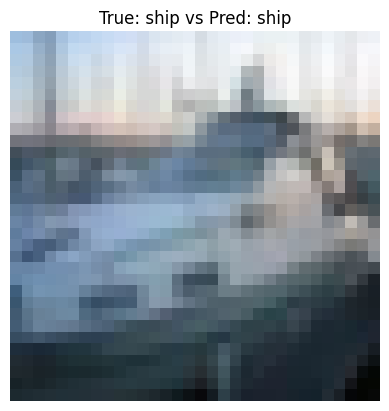

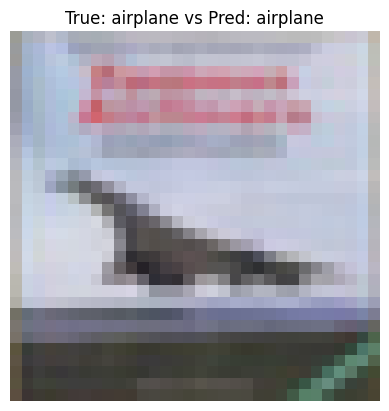

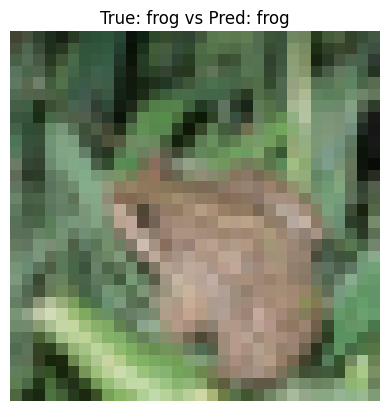

In [ ]:
#Displaying sample predictions with images

def plot_images(index):
    img = X_test[index]
    true_label = class_names[int(y_test[index])]#Actual value
    pred_label = class_names[np.argmax(y_pred[index])]#Predicted value

    plt.imshow(img)
    plt.title(f"True: {true_label} vs Pred: {pred_label}")
    plt.axis('off')
    plt.show()

#Plotting first 5 images
for i in range(5):
    plot_images(i)

# Conclusion
1. Model Performance
   * The CNN model we created has low accuracy as compared to CNN model with transfer learning (in this case InceptionV3) and takes time to converge with higher number of epochs
  
2. Transfer Learning
   * Transfer Learning is effective approach as the pre-trained model has higher ability and trained weights to improve our model performance.Early layers capture low-level features, while deeper layers recognise high-level patterns.We need to consider overfitting factor while using pre-trained models as it can sometimes fail to generalize the model.(If your training accuracy is high but the validation/test accuracy is low-your model is overfitting)

3. Key learnings
   * Use randomseed to reproduce same results over time.
   * Early stopping help us to stop the model training once any significant changes are seen in the monitored parameters.
   * Using pre-trained model gives better accuracy and faster results.